<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-5-Thermodynamics/Untitled168.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Recovering Internal Energy and Entropy**

 We generate synthetic data based on the equation of state for an ideal gas,
$$
PV = cT,
$$
with $c=1$. We sample data points $(P_i, V_i, T_i)$ uniformly from the domain

$$
(P_i, V_i, T_i) \in [0.1, 6] \times [1, 2] \times [0.1, 12], \quad i=1,\dots,N,
$$
with $N=500$.

Using this dataset, we train a PINN, anchoring the solution at the reference point $(P_0, V_0, T_0)) = (1,1,1)$ with

$$
U_0 = U(1,1,1) = 1.5, \qquad S_0 = S(1,1,1) = 1.
$$

To assess the accuracy of the learned solution, we compare it with the exact formulas
$$
U_{\text{exact}} = 1.5\,T, \qquad
S_{\text{exact}} = 1.5 \ln T + \ln V + 1,
$$
where we used that $C_V = 1.5\,c$ for an ideal monoatomic gas.

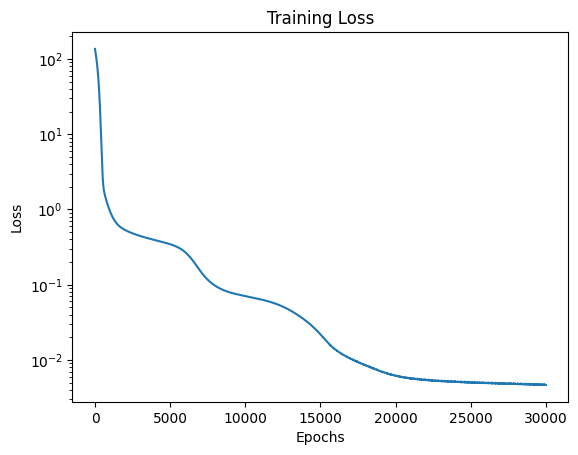

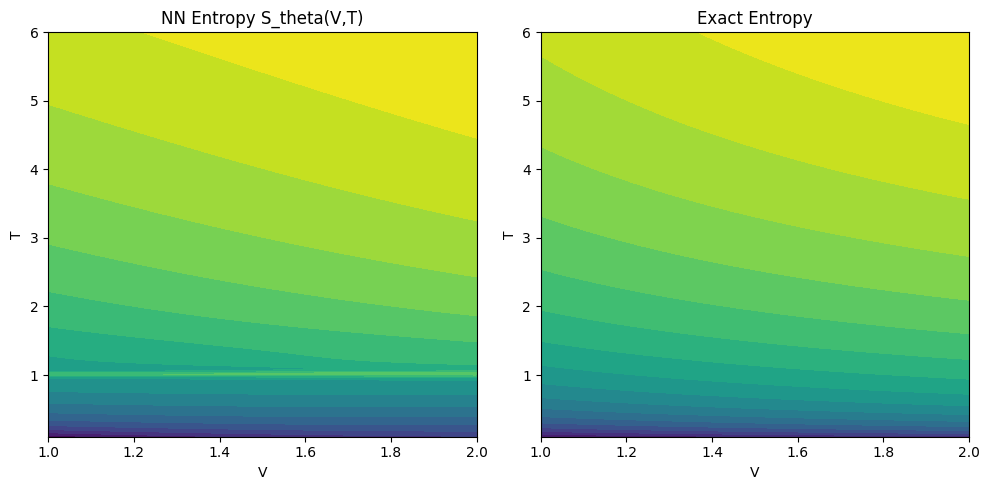

In [ ]:
# ==========================================
# 1. Imports
# ==========================================
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ==========================================
# 2. Synthetic data (ideal gas PV=T,  c=1)
# ==========================================
N = 500
np.random.seed(0)

P = np.random.uniform(0.1, 6.0, (N,1))
V = np.random.uniform(1.0, 2.0, (N,1))
T = P * V

P_tf = tf.convert_to_tensor(P, dtype=tf.float32)
V_tf = tf.convert_to_tensor(V, dtype=tf.float32)
T_tf = tf.convert_to_tensor(T, dtype=tf.float32)

# ==========================================
# 3. Isochoric boundary data (V=1)
# ==========================================
m = 200
T_bd = np.linspace(0.1, 12, m).reshape(-1,1)
V_bd = np.ones_like(T_bd)
P_bd = T_bd  # since PV=T

S_bd = 1.5 * np.log(T_bd)
U_bd = 1.5 * T_bd

T_bd_tf = tf.convert_to_tensor(T_bd, dtype=tf.float32)
V_bd_tf = tf.convert_to_tensor(V_bd, dtype=tf.float32)
P_bd_tf = tf.convert_to_tensor(P_bd, dtype=tf.float32)
S_bd_tf = tf.convert_to_tensor(S_bd, dtype=tf.float32)
U_bd_tf = tf.convert_to_tensor(U_bd, dtype=tf.float32)

# ==========================================
# 4. Anchor
# ==========================================
P0, V0, T0 = 1.0, 1.0, 1.0
U0, S0 = 1.5, 1.0

# ==========================================
# 5. Neural network
# ==========================================
model = tf.keras.Sequential([
    tf.keras.Input(shape=(3,)),
    tf.keras.layers.Dense(64, activation='swish'),
    tf.keras.layers.Dense(64, activation='swish'),
    tf.keras.layers.Dense(64, activation='swish'),
    tf.keras.layers.Dense(2)  # outputs U, S
])

optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)

# ==========================================
# 6. Training step
# ==========================================
@tf.function
def train_step(P, V, T, P_bd, V_bd, T_bd, U_bd, S_bd):

    with tf.GradientTape() as tape_outer:

        # ===== PDE part =====
        with tf.GradientTape(persistent=True) as tape_inner:
            tape_inner.watch([P, V])

            X = tf.concat([P, V, T], axis=1)
            US = model(X)

            U = US[:,0:1]
            S = US[:,1:2]

        U_P = tape_inner.gradient(U, P)
        U_V = tape_inner.gradient(U, V)
        S_P = tape_inner.gradient(S, P)
        S_V = tape_inner.gradient(S, V)

        loss_pde = tf.reduce_mean((U_P - T*S_P)**2) + \
                   tf.reduce_mean((U_V - (T*S_V - P))**2)

        # ===== Anchor =====
        X0 = tf.constant([[P0, V0, T0]], dtype=tf.float32)
        U0_pred, S0_pred = tf.split(model(X0), 2, axis=1)

        loss_ic = tf.reduce_mean((U0_pred - U0)**2 + (S0_pred - S0)**2)

        # ===== Boundary (isochoric) =====
        X_bd = tf.concat([P_bd, V_bd, T_bd], axis=1)
        U_bd_pred, S_bd_pred = tf.split(model(X_bd), 2, axis=1)

        loss_bd = tf.reduce_mean((S_bd_pred - S_bd)**2) + \
                  tf.reduce_mean((U_bd_pred - U_bd)**2)

        loss = loss_pde + loss_ic + loss_bd

    grads = tape_outer.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    return loss

# ==========================================
# 7. Training loop
# ==========================================
epochs = 30000
loss_hist = []

for ep in range(epochs):
    loss = train_step(P_tf, V_tf, T_tf,
                      P_bd_tf, V_bd_tf, T_bd_tf,
                      U_bd_tf, S_bd_tf)
    loss_hist.append(float(loss.numpy()))

# ==========================================
# 8. Plot loss
# ==========================================
plt.figure()
plt.plot(loss_hist)
plt.yscale('log')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

# ==========================================
# 9. Compare entropy surfaces
# ==========================================
V_vals = np.linspace(1, 2, 300)
T_vals = np.linspace(0.1, 6, 300)

V_grid, T_grid = np.meshgrid(V_vals, T_vals)
P_grid = T_grid / V_grid

X_grid = np.stack([
    P_grid.flatten(),
    V_grid.flatten(),
    T_grid.flatten()
], axis=1)

US_pred = model.predict(X_grid, verbose=0)
S_pred = US_pred[:,1].reshape(T_grid.shape)

S_exact = 1.5*np.log(T_grid) + np.log(V_grid) + 1

# ==========================================
# 10. Plot comparison (S surfaces)
# ==========================================
plt.figure(figsize=(10,5))

# NN
plt.subplot(1,2,1)
plt.contourf(V_grid, T_grid, S_pred, levels=20)
plt.title("NN Entropy S_theta(V,T)")
plt.xlabel("V")
plt.ylabel("T")

# Exact
plt.subplot(1,2,2)
plt.contourf(V_grid, T_grid, S_exact, levels=20)
plt.title("Exact Entropy")
plt.xlabel("V")
plt.ylabel("T")

plt.tight_layout()
plt.show()

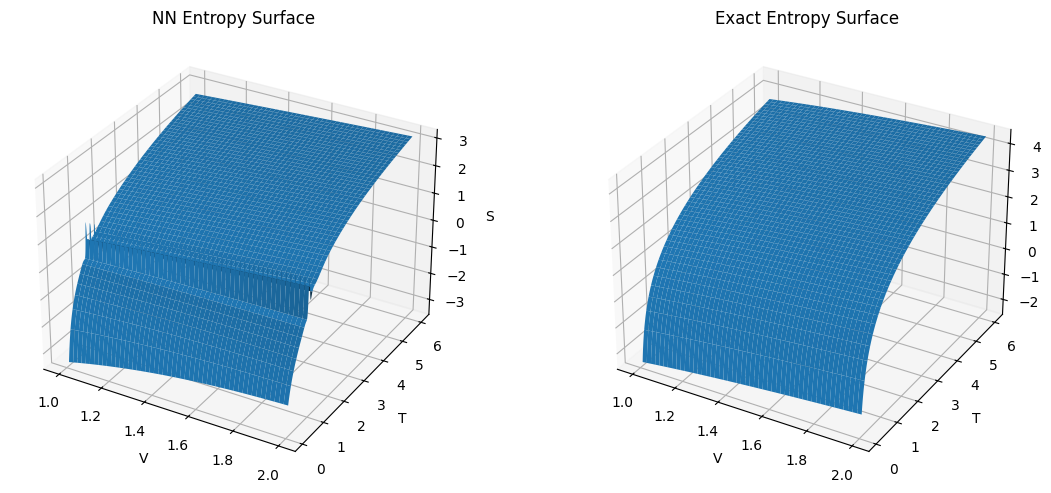

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assume you already trained your model and have it loaded:
# model: NN(P,V,T) -> (U,S)

# ==========================================
# Create grid
# ==========================================
V_vals = np.linspace(1, 2, 2000)
T_vals = np.linspace(0.1, 6, 2000)

V, T = np.meshgrid(V_vals, T_vals)
P = T / V  # ideal gas EOS

# ==========================================
# Exact entropy
# ==========================================
S_exact = 1.5 * np.log(T) + np.log(V) + 1

# ==========================================
# NN entropy
# ==========================================
X = np.stack([P.flatten(), V.flatten(), T.flatten()], axis=1)

US_pred = model.predict(X, verbose=0)
S_nn = US_pred[:,1].reshape(T.shape)

# ==========================================
# Plot
# ==========================================
fig = plt.figure(figsize=(12,5))



# ---- NN surface ----
ax2 = fig.add_subplot(121, projection='3d')
ax2.plot_surface(V, T, S_nn)
ax2.set_xlabel('V')
ax2.set_ylabel('T')
ax2.set_zlabel('S')
ax2.set_title('NN Entropy Surface')

# ---- Exact surface ----
ax1 = fig.add_subplot(122, projection='3d')
ax1.plot_surface(V, T, S_exact)
ax1.set_xlabel('V')
ax1.set_ylabel('T')
ax1.set_zlabel('S')
ax1.set_title('Exact Entropy Surface')

plt.tight_layout()
plt.show()